<a href="https://colab.research.google.com/github/Francisco-Alfredo/Fraud-detection-analysis/blob/main/Fraud_Detection_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ============================================================
# 1. Imports e Carregamento dos Dados
# ============================================================

In [ ]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 6)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
folder = '/content/drive/MyDrive/base de dados/fraud_detection_analysis'

In [ ]:
file = os.listdir(folder)
file

['Fraud Detection Dataset.csv']

In [ ]:

df = pd.read_csv(os.path.join(folder, file[0]))
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


# ============================================================
# 2. EDA — Análise Exploratória
# ============================================================

In [ ]:
df.describe(include='all')

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
count,51000,51000.000000,48480.000000,51000,48448.000000,48527,48453,51000.000000,51000.000000,51000.000000,48531,51000.000000
unique,50000,NaN,NaN,5,NaN,4,8,NaN,NaN,NaN,5,NaN
top,T49147,NaN,NaN,Bill Payment,NaN,Desktop,Boston,NaN,NaN,NaN,UPI,NaN
freq,2,NaN,NaN,10340,NaN,15795,6149,NaN,NaN,NaN,11887,NaN
mean,NaN,3005.110176,2996.249784,NaN,11.488400,NaN,NaN,1.995725,60.033902,7.495588,NaN,0.049216
std,NaN,1153.121107,5043.932555,NaN,6.922954,NaN,NaN,1.415150,34.384131,4.020080,NaN,0.216320
min,NaN,1000.000000,5.030000,NaN,0.000000,NaN,NaN,0.000000,1.000000,1.000000,NaN,0.000000
25%,NaN,2007.000000,1270.552500,NaN,5.000000,NaN,NaN,1.000000,30.000000,4.000000,NaN,0.000000
50%,NaN,2996.000000,2524.100000,NaN,12.000000,NaN,NaN,2.000000,60.000000,7.000000,NaN,0.000000
75%,NaN,4006.000000,3787.240000,NaN,17.000000,NaN,NaN,3.000000,90.000000,11.000000,NaN,0.000000


In [ ]:
#Valores Missing por coluna
df.isna().sum().sort_values(ascending=False)

,0
Time_of_Transaction,2552
Location,2547
Transaction_Amount,2520
Device_Used,2473
Payment_Method,2469
Transaction_Type,0
Transaction_ID,0
User_ID,0
Previous_Fraudulent_Transactions,0
Account_Age,0


#=================================================================
Análisando a distribuição dos valores na coluna Transaction_Amount
#=================================================================

In [ ]:
df['Transaction_Amount'].min()

5.03

In [ ]:
df['Transaction_Amount'].mode()

,Transaction_Amount
0,49997.8


In [ ]:
df['Transaction_Amount'].mean()

np.float64(2996.249784447195)

In [ ]:
df['Transaction_Amount'].max()

49997.8

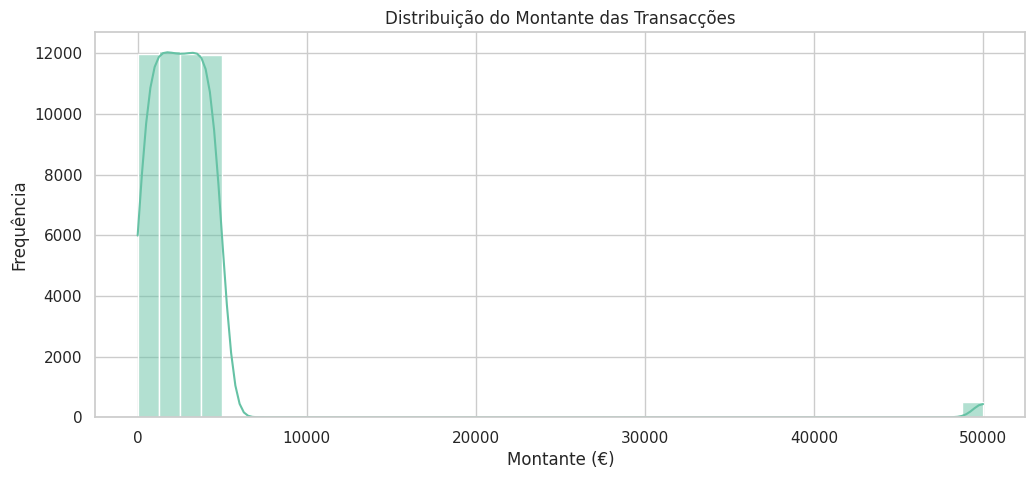

In [ ]:
plt.figure(figsize=(12,5))
sns.histplot(df["Transaction_Amount"], bins=40, kde=True)
plt.title("Distribuição do Montante das Transacções")
plt.xlabel("Montante (€)")
plt.ylabel("Frequência")
plt.show()


Text(0.5, 0, 'Montante (€)')

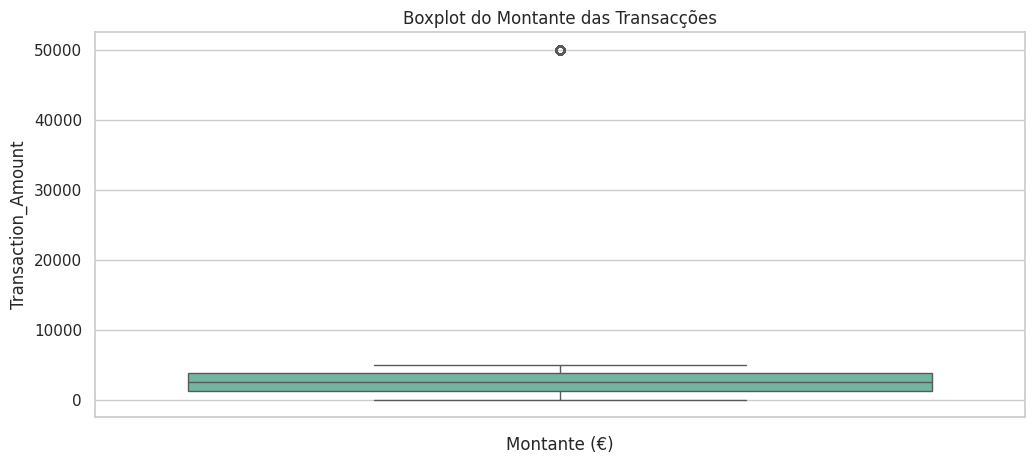

In [ ]:
#
plt.figure(figsize=(12,5))
sns.boxplot(df["Transaction_Amount"])
plt.title("Boxplot do Montante das Transacções")
plt.xlabel("Montante (€)")

<p>Fazendo uma primeira análise descritiva na coluna Transaction_Amount, verificamos que o valor minimo de transação é 5,03 euros, o valor máximo é de 49997,8 euros e o valor que mais repete é 49997,8.</p>
<p><ol><b>Assimetria Elevada:</b> O histograma e o boxplot mostram claramente que a distribuição de Transaction_Amount é altamente assimétrica à direita. Isso significa que a grande maioria das transações envolve valores menores.</ol></p>
<p><ol><b>Outliers e Transações Grandes:</b> Existem outliers significativos, representando transações com valores muito altos, atingindo o máximo de 49997.8. Essas transações grandes são visíveis como a cauda longa no histograma e como pontos individuais além do limite superior no boxplot. Embora possam ser legítimas, em detecção de fraude, tais anomalias frequentemente justificam uma investigação mais aprofundada.</ol></p>
<p><ol><b>Concentração em Valores Baixos:</b> A maioria das transações está concentrada na extremidade inferior do espectro, indicando que as transações típicas são de quantias relativamente modestas.</ol></p>
<p><ol><b>Moda no Valor Máximo:</b> Curiosamente, a moda (49997.8) da Transaction_Amount é também o valor máximo. Isso sugere que este valor máximo específico ocorre com mais frequência do que qualquer outro valor de transação individual. Isso pode ser devido a um limite máximo para os valores das transações ou a um tipo específico de transação que frequentemente atinge esse limite superior. Esta é uma característica incomum para uma variável contínua e pode valer a pena explorar mais a fundo.</ol></p>
